# Spectral and temporal modifications Lab
**Student :** Mohamed Yassine KHALES

*From R. Badeau and G. Richard (with help from P. Vernhet); MAJ:2019,2024*

**python version >=3.6**

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython
from copy import deepcopy
from math import ceil
import soundfile as sf

## Functions

In [17]:
def plot_sound(data, times, name="default_name", save=False):
    plt.figure(figsize=(30, 4))
    plt.fill_between(times, data)
    plt.xlim(times[0], times[-1])
    plt.xlabel("time (s)")
    plt.ylabel("amplitude")
    if save:
        plt.savefig(name + ".png", dpi=100)
    plt.show()


def nextpow2(x):
    assert x > 0
    p = ceil(np.log2(x))
    x_ = 2**p
    assert 2 ** (p - 1) < x <= x_
    return x_


def period(x, Fs, Pmin=1 / 300, Pmax=1 / 80, seuil=0.7):
    # [P,voiced] = period(x,Fs,Pmin,Pmax,seuil);
    # If voiced = 1, P is the period signal x expressed in number of samples
    # If voiced = 0, P is equal to 10ms.Fs

    x = x - np.mean(x)
    N = len(x)

    Nmin = np.ceil(Pmin * Fs).astype(int)
    Nmax = 1 + np.floor(Pmax * Fs).astype(int)
    Nmax = np.min([Nmax, N])

    Nfft = nextpow2(2 * N - 1)
    X = np.fft.fft(x, n=Nfft)
    S = X * np.conj(X) / N
    r = np.real(np.fft.ifft(S))

    rmax = np.max(r[Nmin:Nmax])
    I = np.argmax(r[Nmin:Nmax])
    P = I + Nmin
    corr = (rmax / r[0]) * (N / (N - P))
    voiced = corr > seuil
    if not (voiced):
        P = np.round(10e-3 * Fs)

    return P, voiced

## Reading and playing .wav file

Choose the name of sound for the rest of the notebook. Sounds are assumed to be set in the same directory as the notebook.

In [18]:
filename = 'aeiou.wav'
file_path = os.path.join(os.getcwd(), filename) 

### **Using Soundfile**

In [19]:
x, Fs= sf.read(file_path)

In [20]:
IPython.display.Audio(file_path)

In [21]:
timestep = 1/float(Fs)
times = np.arange(len(x))*timestep

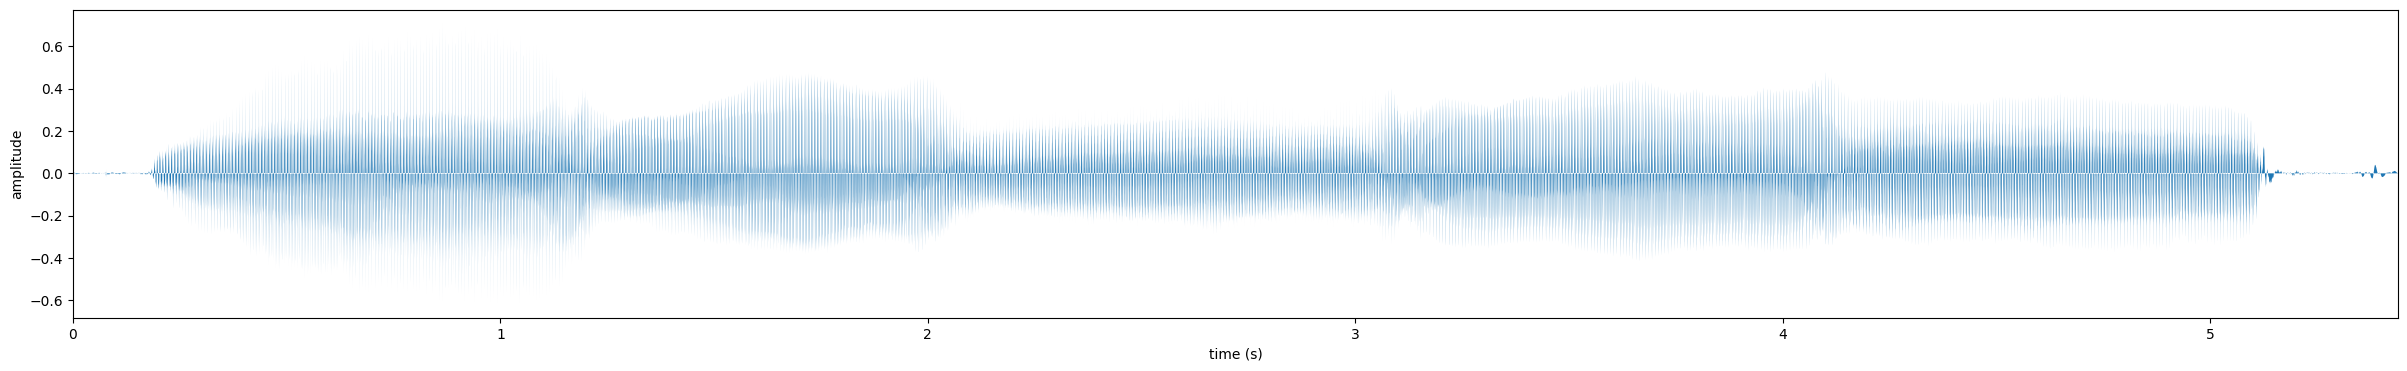

In [22]:
plot_sound(x, times)

In [23]:
sf.write('new_aeiou.wav',x, samplerate=Fs) # to write a new wave file

## 1. Extraction of the analysis marks

In [28]:
def AnalysisPitchMarks(s, Fs):
    N = len(s)
    P0 = int(np.round(10e-3 * Fs))

    ta_list = []
    voiced_list = []
    Pa_list = []

    ta_prev = 0
    Pa_prev = P0

    while ta_prev < N:
        start = ta_prev
        end = min(start + int(np.round(2.5 * Pa_prev)), N)
        seg = s[start:end]

        Nmin_required = int(np.ceil(Fs / 300)) + 1
        if len(seg) <= Nmin_required:
            break
        Pa_n, voiced_n = period(seg, Fs)
        Pa_n = int(np.round(Pa_n))

        ta_n = ta_prev + Pa_n

        ta_list.append(ta_n)
        voiced_list.append(int(voiced_n))
        Pa_list.append(Pa_n)

        ta_prev = ta_n
        Pa_prev = Pa_n

    A = np.array([ta_list, voiced_list, Pa_list])
    return A

In [29]:
A = AnalysisPitchMarks(x, Fs)
print("Number of analysis marks:", A.shape[1])
print("First few marks (ta, voiced, Pa):")
print(A[:, :5])

Number of analysis marks: 707
First few marks (ta, voiced, Pa):
[[110 220 330 440 550]
 [  0   0   0   0   0]
 [110 110 110 110 110]]


## 2. Synthesis and modification

### 2.1 Signal synthesis

In [34]:
import scipy
def Synthesis(s, Fs, A, B):
    ts = B[0, :].astype(int)
    nk = B[1, :].astype(int)

    kend = len(ts) - 1
    n_last = nk[kend]
    Pa_last = int(A[2, n_last])
    y_len = ts[kend] + Pa_last
    y = np.zeros(y_len)

    N = len(s)

    for k in range(len(ts)):
        n = nk[k]
        ta_n = int(A[0, n])
        Pa_n = int(A[2, n])

        start_s = ta_n - Pa_n
        end_s = ta_n + Pa_n + 1
        win_len = 2 * Pa_n + 1

        window = scipy.signal.windows.hann(win_len)

        seg = np.zeros(win_len)
        for i in range(win_len):
            idx = start_s + i
            if 0 <= idx < N:
                seg[i] = s[idx]

        seg_win = seg * window

        out_start = ts[k] - Pa_n
        out_end = ts[k] + Pa_n + 1

        for i in range(win_len):
            idx_y = out_start + i
            if 0 <= idx_y < y_len:
                y[idx_y] += seg_win[i]

    return y

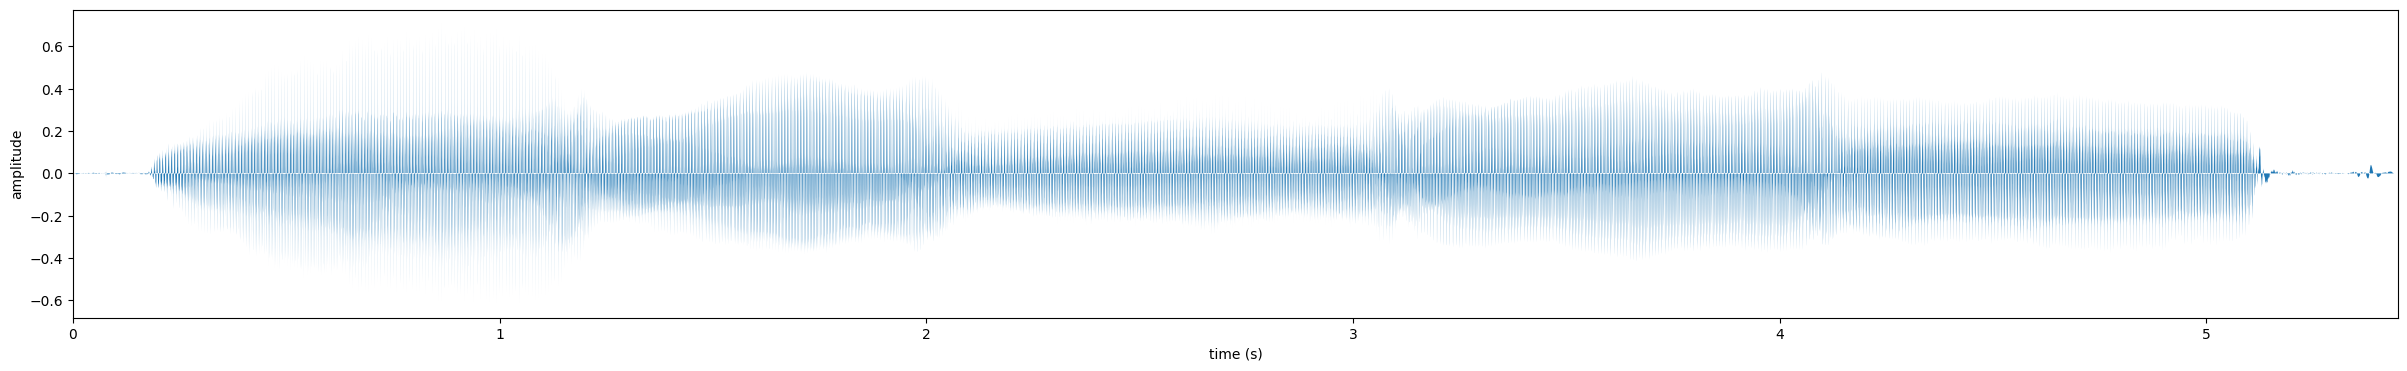

In [35]:
B_identity = np.array([A[0, :], np.arange(A.shape[1])], dtype=int)

y_identity = Synthesis(x, Fs, A, B_identity)

times_y = np.arange(len(y_identity)) / Fs
plot_sound(y_identity, times_y)
IPython.display.Audio(y_identity, rate=Fs)

### 2.2 Modification of the temporal scale

In [36]:
def ChangeTimeScale(alpha, A, Fs):
    num_marks = A.shape[1]

    ts_list = []
    nk_list = []

    ts_prev = 1
    nk = 1.0

    while int(np.floor(nk)) < num_marks - 1:
        n_floor = int(np.floor(nk))
        Pa_n = int(A[2, n_floor])

        ts_k = ts_prev + Pa_n
        ts_list.append(ts_k)
        nk_list.append(n_floor)

        ts_prev = ts_k
        nk = nk + 1.0 / alpha

    B = np.array([ts_list, nk_list], dtype=int)
    return B

Original duration: 5.44s | Modified: 8.13s (x1.5)


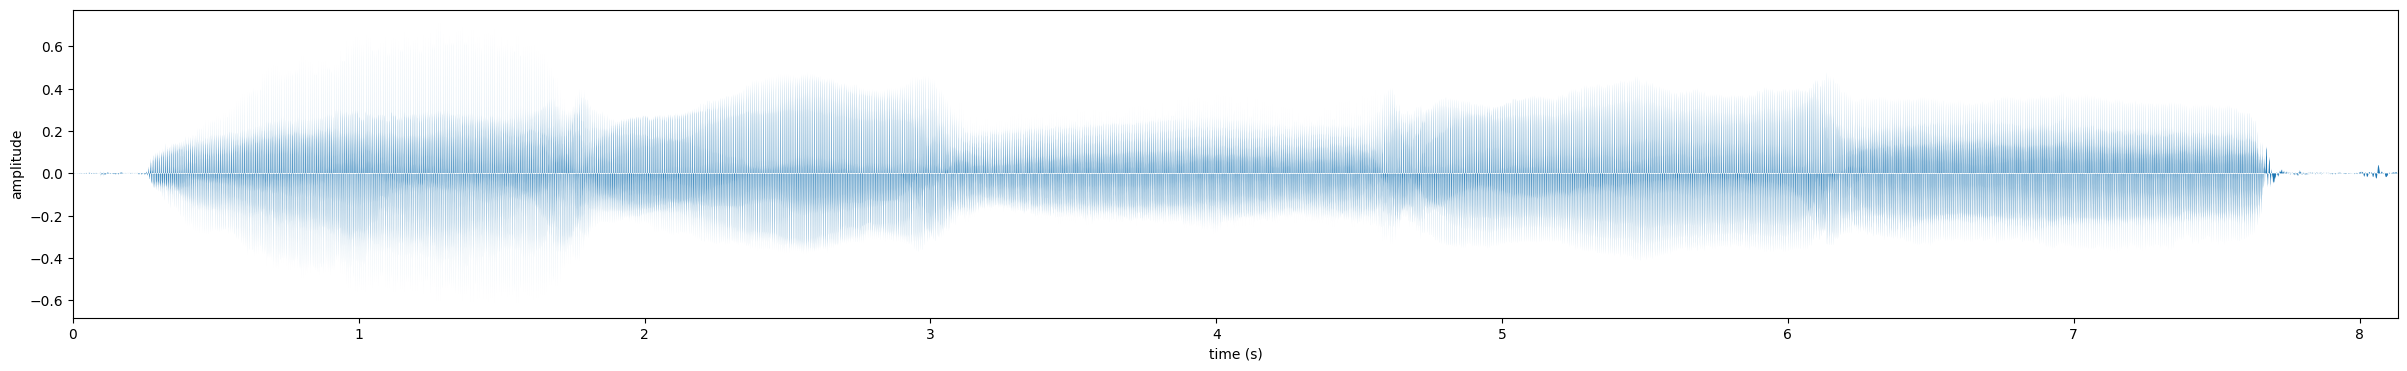

In [37]:
alpha = 1.5
B_time = ChangeTimeScale(alpha, A, Fs)
y_time = Synthesis(x, Fs, A, B_time)

print(f"Original duration: {len(x)/Fs:.2f}s | Modified: {len(y_time)/Fs:.2f}s (x{alpha})")
times_yt = np.arange(len(y_time)) / Fs
plot_sound(y_time, times_yt)
IPython.display.Audio(y_time, rate=Fs)

### 2.3 Modification of the spectral scale 

In [38]:
def ChangePitchScale(beta, A, Fs):
    num_marks = A.shape[1]

    ts_list = []
    nk_list = []

    ts_prev = 1.0
    nk = 1.0

    while int(np.floor(nk)) < num_marks - 1:
        n_floor = int(np.floor(nk))
        voiced_n = A[1, n_floor]
        Pa_n = int(A[2, n_floor])

        scale = 1.0 / beta if voiced_n else 1.0

        ts_k = ts_prev + scale * Pa_n
        ts_list.append(int(np.round(ts_k)))
        nk_list.append(n_floor)

        ts_prev = ts_k
        nk = nk + scale

    B = np.array([ts_list, nk_list], dtype=int)
    return B

Pitch factor: x1.5


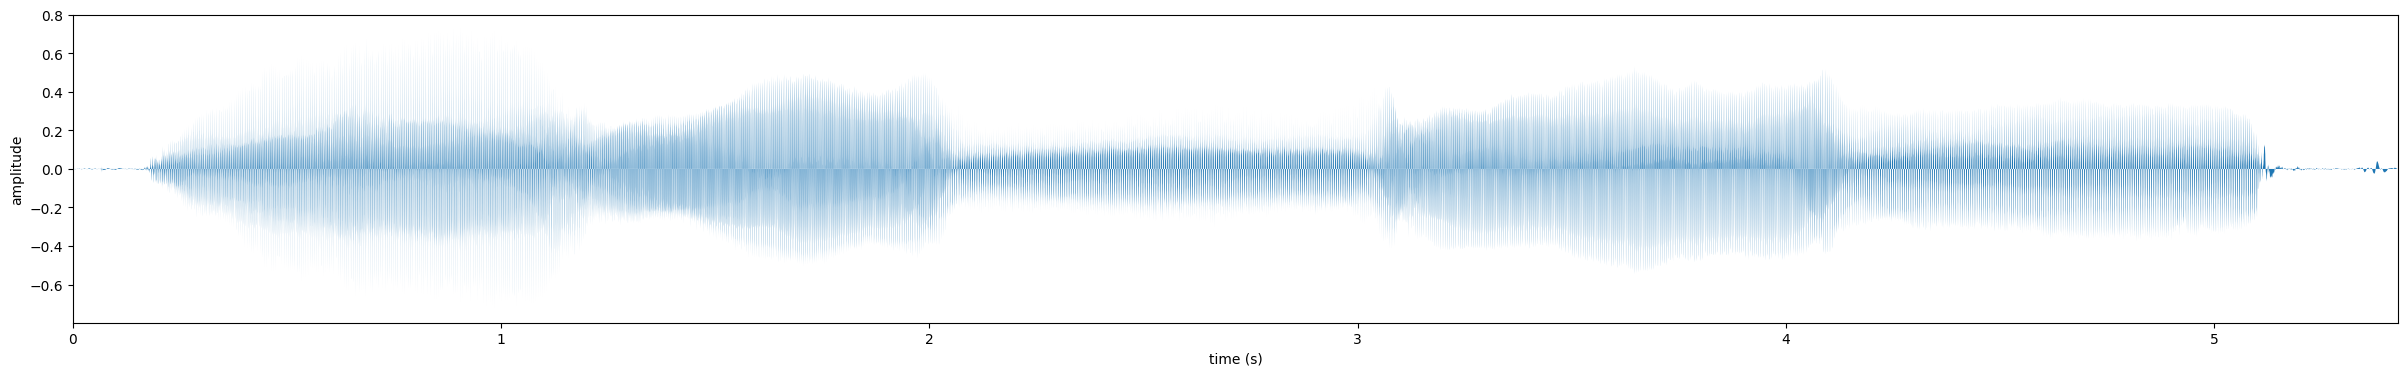

In [39]:
beta = 1.5
B_pitch = ChangePitchScale(beta, A, Fs)
y_pitch = Synthesis(x, Fs, A, B_pitch)

print(f"Pitch factor: x{beta}")
times_yp = np.arange(len(y_pitch)) / Fs
plot_sound(y_pitch, times_yp)
IPython.display.Audio(y_pitch, rate=Fs)

### 2.4 Joint modification of temporal and spectral scales

In [40]:
def ChangeBothScales(alpha, beta, A, Fs):
    num_marks = A.shape[1]

    ts_list = []
    nk_list = []

    ts_prev = 1.0
    nk = 1.0

    while int(np.floor(nk)) < num_marks - 1:
        n_floor = int(np.floor(nk))
        voiced_n = A[1, n_floor]
        Pa_n = int(A[2, n_floor])

        scale = 1.0 / beta if voiced_n else 1.0

        ts_k = ts_prev + scale * Pa_n
        ts_list.append(int(np.round(ts_k)))
        nk_list.append(n_floor)

        ts_prev = ts_k
        nk = nk + scale / alpha

    B = np.array([ts_list, nk_list], dtype=int)
    return B

Time factor: x1.5 | Pitch factor: x1.5
Original duration: 5.44s | Modified: 8.14s


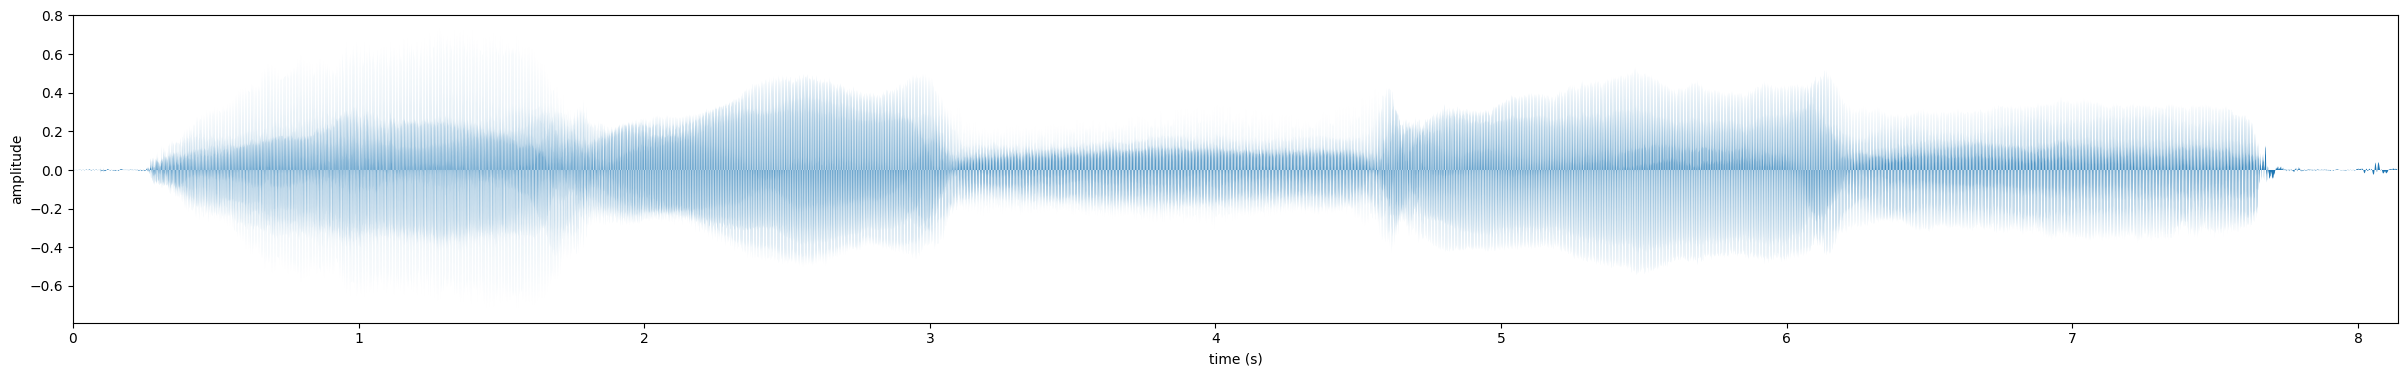

In [41]:
alpha = 1.5
beta = 1.5
B_both = ChangeBothScales(alpha, beta, A, Fs)
y_both = Synthesis(x, Fs, A, B_both)

print(f"Time factor: x{alpha} | Pitch factor: x{beta}")
print(f"Original duration: {len(x)/Fs:.2f}s | Modified: {len(y_both)/Fs:.2f}s")
times_yb = np.arange(len(y_both)) / Fs
plot_sound(y_both, times_yb)
IPython.display.Audio(y_both, rate=Fs)

## Exports

In [42]:
sf.write('aeiou_time_stretched.wav', y_time, samplerate=Fs)
sf.write('aeiou_pitch_shifted.wav', y_pitch, samplerate=Fs)
sf.write('aeiou_both.wav', y_both, samplerate=Fs)